# Exploratory Data Analysis

In [1]:
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from IPython.display import display

from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test

from config import Config
from utils import load_patient_ids, build_id_to_cohort, TDMapDataset, pad_ucsf_ids, unpad_ucsf_ids

pd.set_option("display.max_columns", 50)

# Section 1 - Cohorts & volume loading

Uses `load_patient_ids` (not the merged `clinical_csv`) as the subject population, since
that's what the autoencoder is actually trained on: **1001** subjects (UCSF wildtype-only,
UPENN, RHUH no-prior-treatment-only, TCGA), independent of survival-data completeness.
The merged `clinical_csv` (999 rows) is a separate, survival-filtered artifact used only
downstream for Cox/DeepSurv work - it drops exactly 2 subjects (`UCSF-PDGM-169`: missing
OS days; `RHUH-0008`: missing censoring status) who otherwise have complete imaging data.
Sections 5-6 (which need survival info) will necessarily be restricted to those 999.

In [2]:
cfg = Config()

patient_ids = load_patient_ids(cfg.gbm_root, cfg.cohort_dirs)
patient_ids["ucsf"] = pad_ucsf_ids(patient_ids["ucsf"])  # on-disk folders/files use 4-digit UCSF ids
id_to_cohort = build_id_to_cohort(patient_ids)

print(f"\nCohorts: {list(patient_ids.keys())}")
print(f"Total subjects: {sum(len(v) for v in patient_ids.values())}")

  UCSF     —  368 subjects  (CSV: (368, 27))
  UPENN    —  496 subjects  (CSV: (496, 18))
  RHUH     —   34 subjects  (CSV: (34, 33))
  TCGA     —  103 subjects  (CSV: (103, 22))

  Total: 1001 subjects across 4 cohorts

Cohorts: ['ucsf', 'upenn', 'rhuh', 'tcga']
Total subjects: 1001


Template shape  : (131, 155, 126)
Brain mask shape: (131, 155, 126)
Mask limits     : -0.02473958395421505, 1.0247396230697632


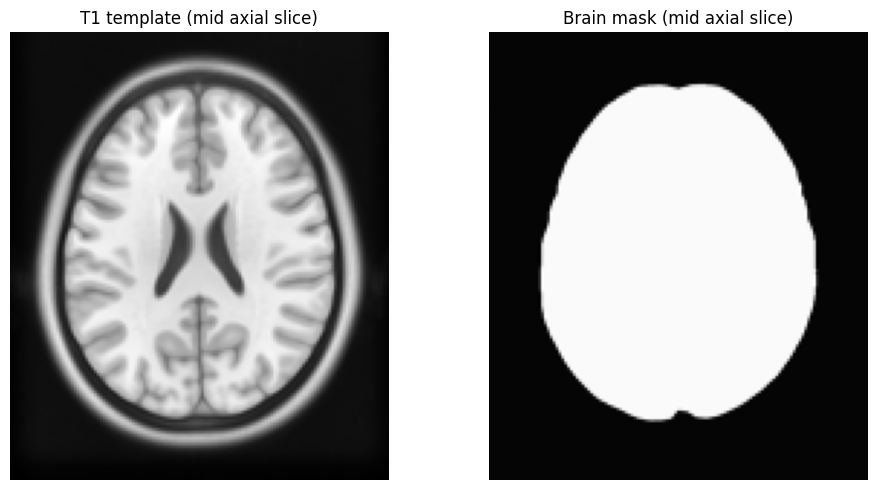

In [3]:
t1 = nib.load(cfg.template)
t1_mask = nib.load(cfg.brain_mask)
t1_data = t1.get_fdata()
mask_data = t1_mask.get_fdata()

print(f"Template shape  : {t1_data.shape}")
print(f"Brain mask shape: {mask_data.shape}")
print(f"Mask limits     : {mask_data.min()}, {mask_data.max()}")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
mid = t1_data.shape[2] // 2
axes[0].imshow(t1_data[:, :, mid].T, cmap="gray", origin="lower")
axes[0].set_title("T1 template (mid axial slice)")
axes[1].imshow(mask_data[:, :, mid].T, cmap="gray", origin="lower")
axes[1].set_title("Brain mask (mid axial slice)")
for ax in axes:
    ax.axis("off")
fig.tight_layout()

In [4]:
FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)
fig.savefig(FIGURES_DIR / "template_vs_brain_mask.pdf", dpi=300, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "template_vs_brain_mask.svg", dpi=300, bbox_inches="tight")

# Section 2 - Demographics & cohort overview

Base population is the full 1001 (from `patient_ids`), left-joined with `clinical_csv` for
age/sex/survival fields where available

In [ ]:
clinical_cols = ["ID", "age", "sex", "eor", "mgmt", "kps (preop)", "OS (days) - corrected", "status"]
clinical = pd.read_csv(cfg.clinical_csv)[clinical_cols]

# clinical_csv uses unpadded UCSF ids (e.g. "UCSF-PDGM-169"), while patient_ids/id_to_cohort
# use the padded on-disk form (e.g. "UCSF-PDGM-0169") - unpad just for this merge, same
# pattern cox.py uses
records = [
    {"ID": unpad_ucsf_ids(sid) if cohort == "ucsf" else sid, "cohort": cohort}
    for cohort, sids in patient_ids.items() for sid in sids
]
overview = pd.DataFrame(records).merge(clinical, on="ID", how="left")

print(f"Total subjects (from load_patient_ids): {len(overview)}")
print(f"Subjects with survival data (in clinical_csv): {overview['OS (days) - corrected'].notna().sum()}")

missing_surv = overview[overview["OS (days) - corrected"].isna()]
print(f"Subjects WITHOUT survival data ({len(missing_surv)}):")
display(missing_surv[["ID", "cohort"]])

Total subjects (from load_patient_ids): 1001
Subjects with survival data (in clinical_csv): 999
Subjects WITHOUT survival data (2):


,ID,cohort
136,UCSF-PDGM-169,ucsf
866,RHUH-0008,rhuh


,N (age known),mean,std,min,median,max
cohort,,,,,,
rhuh,33.0,63.8,9.0,47.0,64.0,78.0
tcga,103.0,58.9,12.9,18.0,59.0,84.0
ucsf,367.0,61.8,12.0,21.0,62.0,94.0
upenn,496.0,63.4,11.5,20.7,63.8,88.5


sex,0.0,1.0
cohort,,
rhuh,22,11
tcga,63,40
ucsf,218,149
upenn,297,199


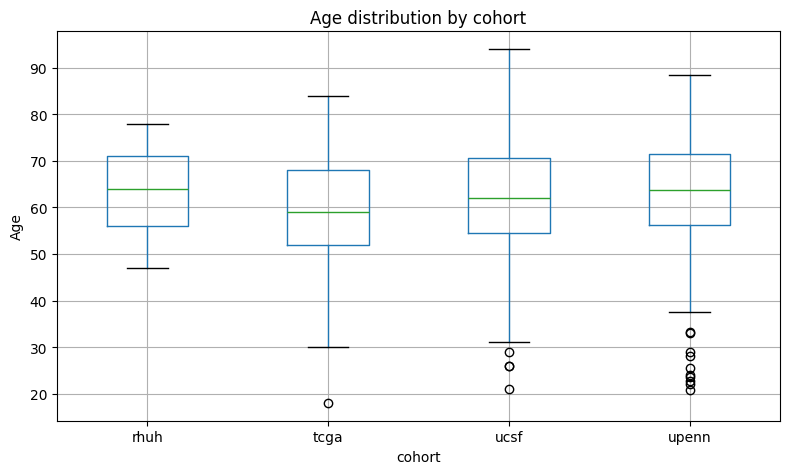

In [6]:
age_summary = overview.groupby("cohort")["age"].describe()[["count", "mean", "std", "min", "50%", "max"]]
age_summary.columns = ["N (age known)", "mean", "std", "min", "median", "max"]
display(age_summary.round(1))

sex_summary = overview.groupby(["cohort", "sex"]).size().unstack(fill_value=0)
display(sex_summary)

fig, ax = plt.subplots(figsize=(8, 5))
overview.boxplot(column="age", by="cohort", ax=ax)
ax.set_ylabel("Age")
ax.set_title("Age distribution by cohort")
plt.suptitle("")
fig.tight_layout()

# Section 3 - TDMap volume stats

One streaming pass over all 1001 raw volumes (`normalisation="none"`, i.e. just the
negative-value clamp `TDMapDataset` always applies - no crop/pad/zscore), computing shape,
min, max, and nonzero-voxel fraction per subject. Cached to `jsons/eda_volume_stats.json`
so this expensive pass only runs once; the cache file needs to be deleted to force a recompute.
Gives the global max needed to build shared histogram bins in Section 4.

In [7]:
EDA_CACHE_DIR = Path(cfg.jsons_dir)
EDA_CACHE_DIR.mkdir(exist_ok=True)
STATS_CACHE_PATH = EDA_CACHE_DIR / "eda_volume_stats.json"

EXPECTED_SHAPE = (131, 155, 126)  # documented raw volume shape

if STATS_CACHE_PATH.exists():
    print(f"Cache already exists at {STATS_CACHE_PATH} -- skipping recompute. Delete it to force a rerun.")
else:
    print("Computing per-subject volume stats -- one pass over all 1001 raw volumes.")
    per_subject = []
    t0 = time.time()
    for cohort, sids in patient_ids.items():
        ds = TDMapDataset(
            subjects=sids, template=cfg.template, root=cfg.gbm_root,
            data_dir=cfg.cohort_dirs[cohort], tissue=cfg.tissue, tdmap=cfg.tdmap,
            voxel_res=cfg.voxel_res, nthreads=cfg.nthreads, normalisation="none",
        )
        for i, sid in enumerate(sids):
            vol = ds[i].squeeze(0).numpy()  # (D, H, W); negative values already clamped to 0
            per_subject.append({
                "id": sid, "cohort": cohort, "shape": list(vol.shape),
                "min": float(vol.min()), "max": float(vol.max()),
                "nonzero_frac": float((vol > 0).mean()),
            })
        print(f"  {cohort}: done ({len(sids)} subjects, {time.time() - t0:.0f}s elapsed)")

    STATS_CACHE_PATH.write_text(json.dumps(per_subject))
    print(f"Saved -> {STATS_CACHE_PATH} ({time.time() - t0:.0f}s total)")

Cache already exists at /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/jsons/eda_volume_stats.json -- skipping recompute. Delete it to force a rerun.


In [8]:
stats_df = pd.DataFrame(json.loads(STATS_CACHE_PATH.read_text()))

bad_shape = stats_df[stats_df["shape"].apply(lambda s: tuple(s) != EXPECTED_SHAPE)]
print(f"Subjects with unexpected raw shape (expected {EXPECTED_SHAPE}): {len(bad_shape)}")
if len(bad_shape):
    display(bad_shape[["id", "cohort", "shape"]])

DEGENERATE_THRESHOLD = 1e-4  # nonzero-voxel fraction below which a volume is flagged
degenerate = stats_df[stats_df["nonzero_frac"] < DEGENERATE_THRESHOLD]
print(f"\nDegenerate volumes (nonzero-voxel fraction < {DEGENERATE_THRESHOLD}): {len(degenerate)}")
if len(degenerate):
    display(degenerate[["id", "cohort", "nonzero_frac", "max"]])

GLOBAL_MIN = float(stats_df["min"].min())
GLOBAL_MAX = float(stats_df["max"].max())
print(f"\nGlobal intensity range across all {len(stats_df)} raw volumes: [{GLOBAL_MIN:.4f}, {GLOBAL_MAX:.4f}]")

display(stats_df.groupby("cohort")["max"].describe()[["count", "mean", "min", "50%", "max"]])

Subjects with unexpected raw shape (expected (131, 155, 126)): 0

Degenerate volumes (nonzero-voxel fraction < 0.0001): 0

Global intensity range across all 1001 raw volumes: [0.0000, 927.4595]


,count,mean,min,50%,max
cohort,,,,,
rhuh,34.0,859.358474,720.450073,905.118256,926.182739
tcga,103.0,834.126557,227.399734,836.172729,926.187378
ucsf,368.0,833.708254,320.732361,840.245880,926.968628
upenn,496.0,828.546108,230.271698,838.197205,927.459473


# Section 4 - Per-cohort TDMap intensity histograms

Second streaming pass (needs `GLOBAL_MAX` from Section 3 to fix shared bin edges across
cohorts first). Memory stays O(n_bins) regardless of cohort size - only one subject's
volume is ever held in memory at a time; per-subject counts are accumulated into a running
per-cohort histogram array. Cached to `jsons/eda_histograms.npz` (bin edges + counts only,
not the raw voxel data) so the compute cell only needs to run once - the plotting cells
below just reload the cache. Cache file needs to be deleted to force a recompute (e.g. if `N_BINS` changes).

Different views, since TDMaps are mostly zero outside tract-intersecting voxels: (a) all voxels,
log-scale y-axis; (b) nonzero voxels only, to see the shape of the actual tract-density
tail. (c) b but scaled to exclude the almost zero values

In [9]:
HIST_CACHE_PATH = EDA_CACHE_DIR / "eda_histograms.npz"
N_BINS = 200

bin_edges = np.linspace(GLOBAL_MIN, GLOBAL_MAX, N_BINS + 1)
nz_edges = np.linspace(1e-6, GLOBAL_MAX, N_BINS + 1)  # nonzero-only view, excludes the zero spike

if HIST_CACHE_PATH.exists():
    print(f"Cache already exists at {HIST_CACHE_PATH} -- skipping recompute. Delete it to force a rerun.")
else:
    print("Accumulating per-cohort histograms (streaming, one volume in memory at a time)...")
    hist_all = {c: np.zeros(N_BINS) for c in patient_ids}
    hist_nz = {c: np.zeros(N_BINS) for c in patient_ids}
    t0 = time.time()
    for cohort, sids in patient_ids.items():
        ds = TDMapDataset(
            subjects=sids, template=cfg.template, root=cfg.gbm_root,
            data_dir=cfg.cohort_dirs[cohort], tissue=cfg.tissue, tdmap=cfg.tdmap,
            voxel_res=cfg.voxel_res, nthreads=cfg.nthreads, normalisation="none",
        )
        for i in range(len(sids)):
            vol = ds[i].squeeze(0).numpy().ravel()
            hist_all[cohort] += np.histogram(vol, bins=bin_edges)[0]
            nz = vol[vol > 0]
            if nz.size:
                hist_nz[cohort] += np.histogram(nz, bins=nz_edges)[0]
        print(f"  {cohort}: done ({time.time() - t0:.0f}s elapsed)")

    np.savez(
        HIST_CACHE_PATH,
        bin_edges=bin_edges, nz_edges=nz_edges,
        **{f"all_{c}": h for c, h in hist_all.items()},
        **{f"nz_{c}": h for c, h in hist_nz.items()},
    )
    print(f"Saved -> {HIST_CACHE_PATH} ({time.time() - t0:.0f}s total)")

Cache already exists at /home/joan/Desktop/PROJECTS/Julia/code/dl-tract-density-survival/jsons/eda_histograms.npz -- skipping recompute. Delete it to force a rerun.


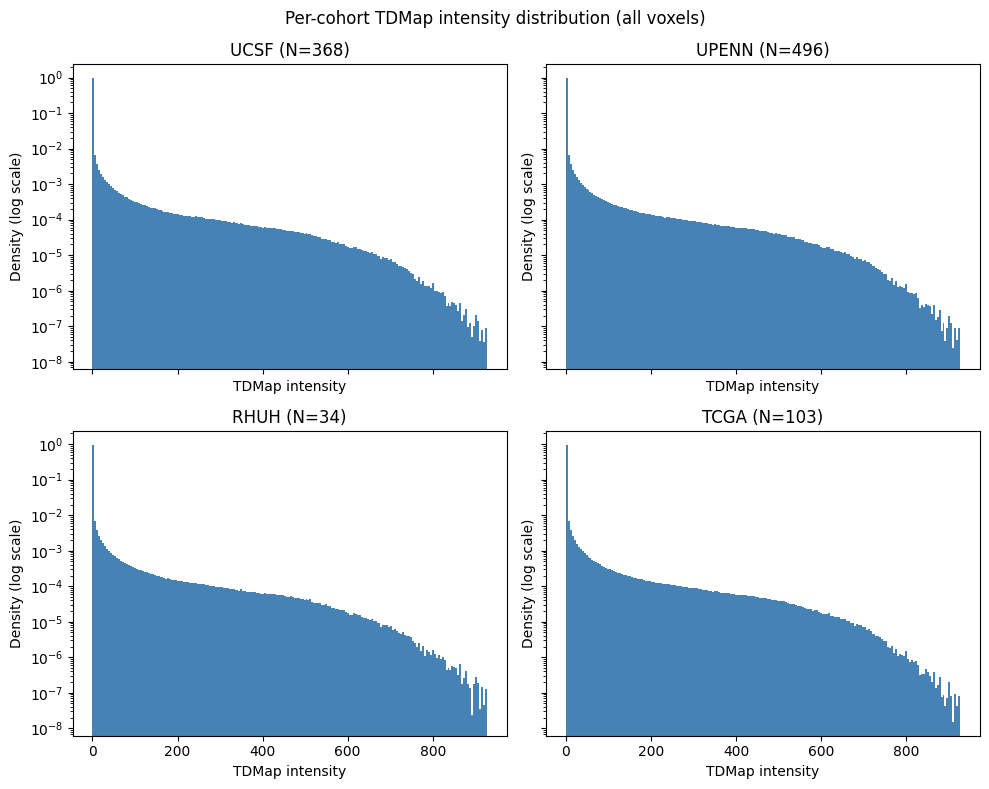

In [10]:
cached = np.load(HIST_CACHE_PATH)
_bin_edges = cached["bin_edges"]
_bin_centers = (_bin_edges[:-1] + _bin_edges[1:]) / 2
_bin_widths = np.diff(_bin_edges)

cohorts = list(patient_ids.keys())
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, cohort in zip(axes.ravel(), cohorts):
    counts = cached[f"all_{cohort}"]
    density = counts / counts.sum()
    ax.bar(_bin_centers, density, width=_bin_widths, color="steelblue")
    ax.set_yscale("log")
    ax.set_title(f"{cohort.upper()} (N={len(patient_ids[cohort])})")
    ax.set_xlabel("TDMap intensity")
    ax.set_ylabel("Density (log scale)")
fig.suptitle("Per-cohort TDMap intensity distribution (all voxels)")
fig.tight_layout()

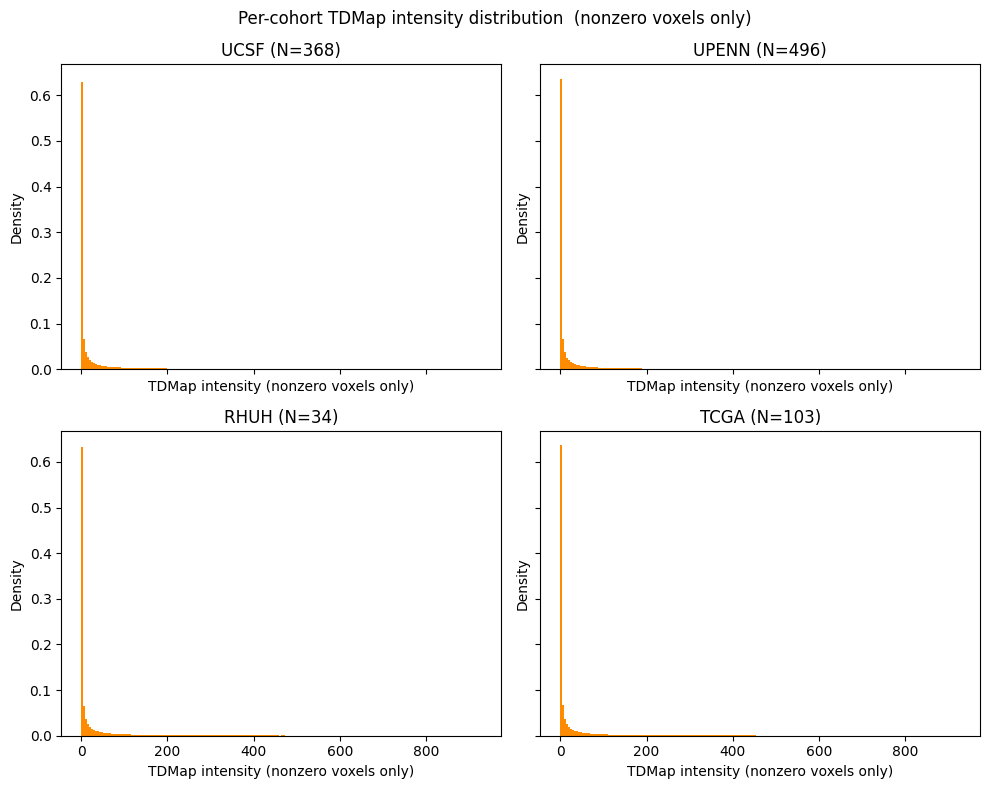

In [11]:
_nz_edges = cached["nz_edges"]
_nz_centers = (_nz_edges[:-1] + _nz_edges[1:]) / 2
_nz_widths = np.diff(_nz_edges)

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True, sharey=True)
for ax, cohort in zip(axes.ravel(), cohorts):
    counts = cached[f"nz_{cohort}"]
    density = counts / counts.sum()
    ax.bar(_nz_centers, density, width=_nz_widths, color="darkorange")
    ax.set_title(f"{cohort.upper()} (N={len(patient_ids[cohort])})")
    ax.set_xlabel("TDMap intensity (nonzero voxels only)")
    ax.set_ylabel("Density")
fig.suptitle("Per-cohort TDMap intensity distribution  (nonzero voxels only)")
fig.tight_layout()

### Zoomed-in linear histogram 

Drops the dominant first bin from view - x-axis starts at `ZOOM_MIN=5` (just past the first bin's right edge, ~4.64) and runs out to the natural max (~927), not capped. Y-axis rescaled to whatever's visible. Resolution is
capped at the existing bin width (~4.64, since `N_BINS=200` spans the full `[0, 927]`
range)

Zoomed histogram starts at x = 5 (dominant first bin [0, 4.6373) excluded)


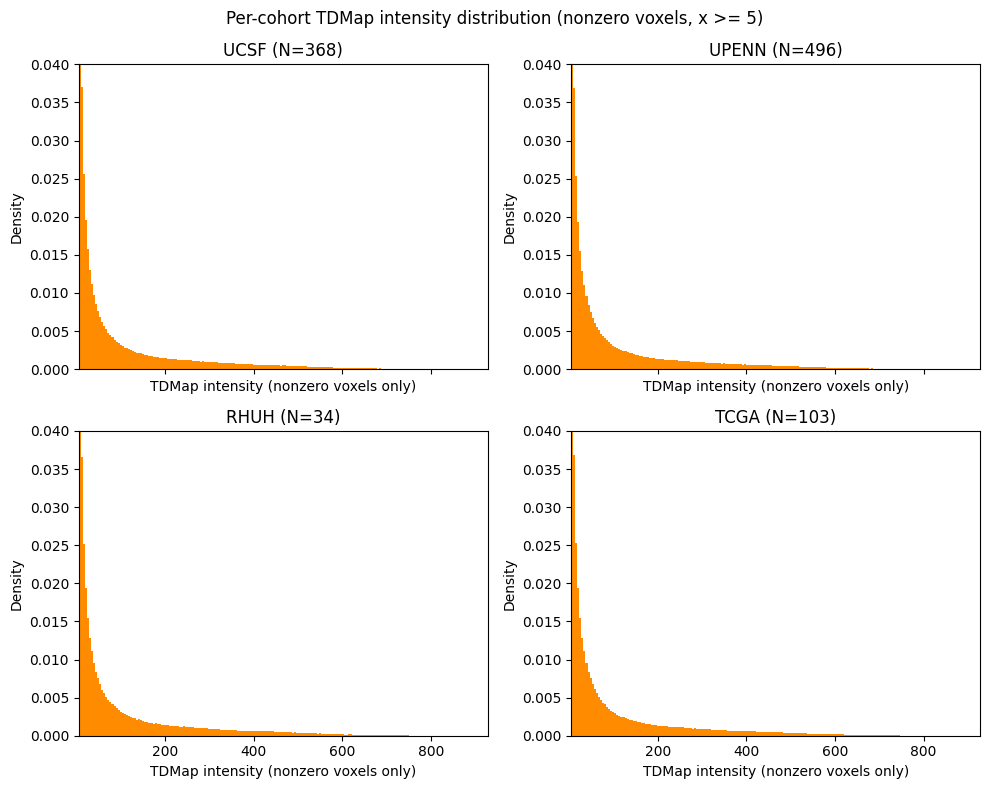

In [ ]:
ZOOM_MIN = 5  # excludes the dominant first bin (which spans [0, 4.64)) entirely

visible = (_nz_centers >= ZOOM_MIN) & (_nz_centers <= GLOBAL_MAX)
print(f"Zoomed histogram starts at x = {ZOOM_MIN} (dominant first bin [0, {_nz_edges[1]:.4f}) excluded)")

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for ax, cohort in zip(axes.ravel(), cohorts):
    counts = cached[f"nz_{cohort}"]
    density = counts / counts.sum()
    ax.bar(_nz_centers, density, width=_nz_widths, color="darkorange")
    ax.set_xlim(ZOOM_MIN, GLOBAL_MAX)
    ax.set_ylim(0, 0.04)
    ax.set_title(f"{cohort.upper()} (N={len(patient_ids[cohort])})")
    ax.set_xlabel("TDMap intensity (nonzero voxels only)")
    ax.set_ylabel("Density")
fig.suptitle(f"Per-cohort TDMap intensity distribution (nonzero voxels, x >= {ZOOM_MIN})")
fig.tight_layout()

# Section 5 - Cohort summary table

In [13]:
surv = overview.dropna(subset=["status"]).copy()
surv["status"] = surv["status"].astype(int)

summary = surv.groupby("cohort").agg(N=("ID", "count"), events=("status", "sum")).reset_index()
summary["censored"] = summary["N"] - summary["events"]
summary["censoring_rate_%"] = (summary["censored"] / summary["N"] * 100).round(1)

total_row = pd.DataFrame([{
    "cohort": "TOTAL",
    "N": summary["N"].sum(),
    "events": summary["events"].sum(),
    "censored": summary["censored"].sum(),
    "censoring_rate_%": round(summary["censored"].sum() / summary["N"].sum() * 100, 1),
}])
summary = pd.concat([summary, total_row], ignore_index=True)
summary

,cohort,N,events,censored,censoring_rate_%
0,rhuh,33,24,9,27.3
1,tcga,103,82,21,20.4
2,ucsf,367,223,144,39.2
3,upenn,496,482,14,2.8
4,TOTAL,999,811,188,18.8


# Section 6 - Survival-time distributions per cohort

Uses `OS (days) - corrected`. Kaplan-Meier curves per cohort with a log-rank test for whether cohorts differ significantly.

Log-rank test across cohorts: p = 0.9576


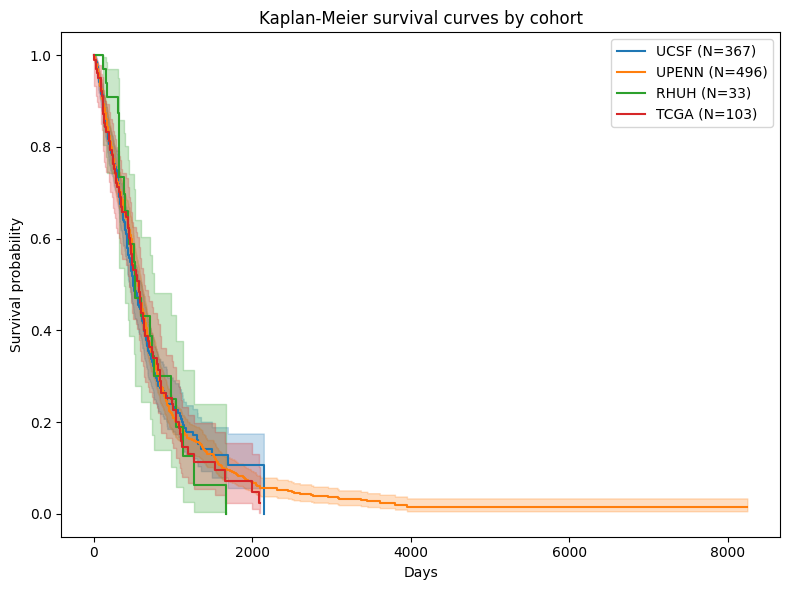

In [14]:
fig, ax = plt.subplots(figsize=(8, 6))
for cohort in patient_ids:
    mask = surv["cohort"] == cohort
    kmf = KaplanMeierFitter(label=f"{cohort.upper()} (N={mask.sum()})")
    kmf.fit(surv.loc[mask, "OS (days) - corrected"], event_observed=surv.loc[mask, "status"])
    kmf.plot_survival_function(ax=ax)
ax.set_xlabel("Days")
ax.set_ylabel("Survival probability")
ax.set_title("Kaplan-Meier survival curves by cohort")
fig.tight_layout()

logrank_result = multivariate_logrank_test(
    surv["OS (days) - corrected"], surv["cohort"], surv["status"]
)
print(f"Log-rank test across cohorts: p = {logrank_result.p_value:.4g}")

# Section 7 - MGMT / EOR / KPS covariates exploration

In [15]:
covariates = ["mgmt", "eor", "kps (preop)"]

missingness = overview.groupby("cohort")[covariates].apply(lambda d: d.isna().mean() * 100).round(1)
missingness.columns = [f"{c} missing %" for c in covariates]
display(missingness)

print("\nMGMT value counts by cohort:")
display(overview.groupby("cohort")["mgmt"].value_counts(dropna=False).unstack(fill_value=0))

print("\nEOR value counts by cohort:")
display(overview.groupby("cohort")["eor"].value_counts(dropna=False).unstack(fill_value=0))

,mgmt missing %,eor missing %,kps (preop) missing %
cohort,,,
rhuh,100.0,2.9,2.9
tcga,36.9,100.0,17.5
ucsf,3.5,0.3,100.0
upenn,43.8,4.8,84.9



MGMT value counts by cohort:


mgmt,0.0,1.0,2.0,NaN
cohort,,,,
rhuh,0,0,0,34
tcga,37,0,28,38
ucsf,104,5,246,13
upenn,151,25,103,217



EOR value counts by cohort:


eor,0.0,1.0,2.0,NaN
cohort,,,,
rhuh,0,0,33,1
tcga,0,0,0,103
ucsf,41,112,214,1
upenn,0,180,292,24
